In [1]:
!pip uninstall scikit-learn -y
!pip install -U scikit-learn
!

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)


In [3]:
import sklearn
print(f"Scikit-learn version: {sklearn.__version__}")
from sklearn.linear_model import LinearRegression
print("Success! Model imported.")

Scikit-learn version: 1.8.0
Success! Model imported.


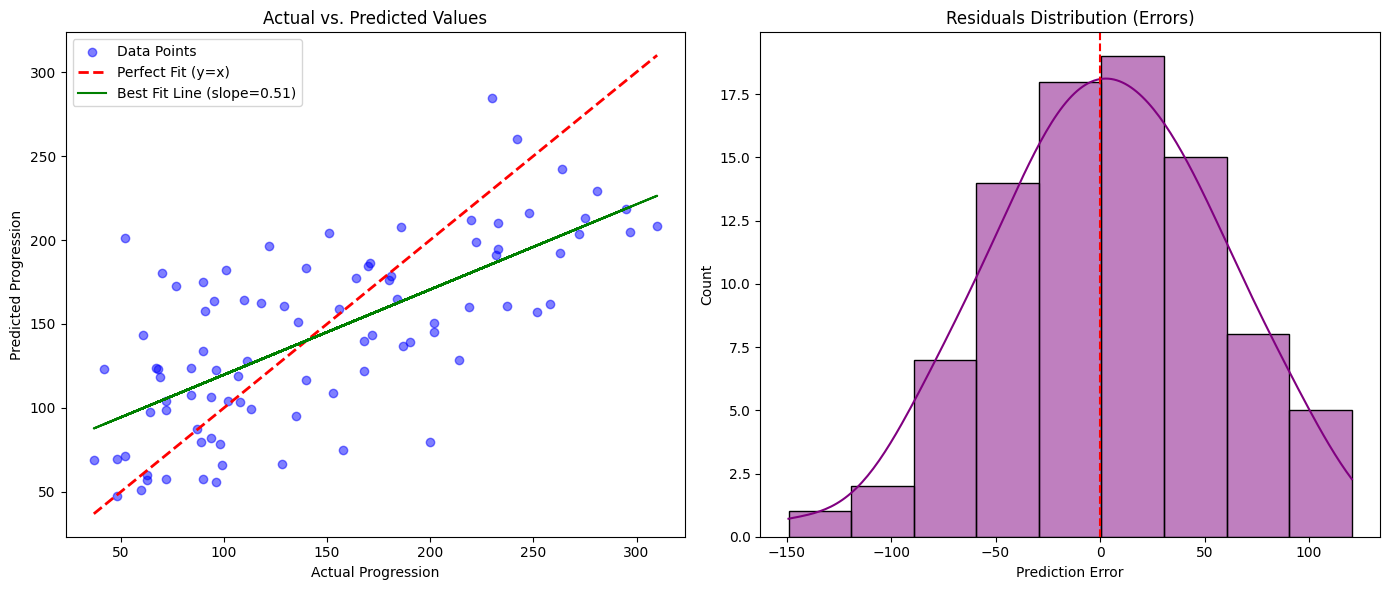

Selected Features: ['sex', 'bmi', 'bp', 's3', 's5']
R2 Score: 0.4694


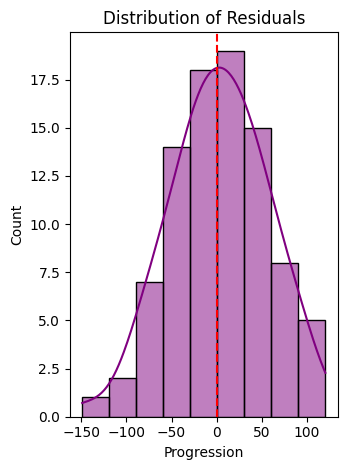

Selected Features: ['sex', 'bmi', 'bp', 's3', 's5']
R-squared Score: 0.4694


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import r2_score

# 1. Load the Diabetes Dataset
diabetes = load_diabetes()
data = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
data['Progression'] = diabetes.target

# 2. Feature Engineering
data['BMI_BP_Interaction'] = data['bmi'] * data['bp']
data['BMI_Squared'] = data['bmi'] ** 2
X = data.drop('Progression', axis=1)
y = data['Progression']

# FIX: Added train_test_split (previously missing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Stepwise Feature Selection
model = LinearRegression()
sfs_forward = SequentialFeatureSelector(model, n_features_to_select=5, direction='forward')
sfs_forward.fit(X_train, y_train)
forward_features = X.columns[sfs_forward.get_support()]

# 4. Final Model Training
X_train_sel = X_train[forward_features]
X_test_sel = X_test[forward_features]
final_model = LinearRegression()
final_model.fit(X_train_sel, y_train)

# 5. Evaluation
y_pred = final_model.predict(X_test_sel)

# 6. Visualizations
plt.figure(figsize=(14, 6))

# Subplot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Data Points')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2, label='Perfect Fit (y=x)')
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m*y_test + b, color='green', label=f'Best Fit Line (slope={m:.2f})')
plt.xlabel('Actual Progression')
plt.ylabel('Predicted Progression')
plt.title('Actual vs. Predicted Values')
plt.legend()

# Subplot 2: Residual Plot (Crucial for Linear Regression diagnostics)
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residuals Distribution (Errors)')
plt.xlabel('Prediction Error')

plt.tight_layout()
plt.show()

print(f"Selected Features: {list(forward_features)}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# Subplot 2: Residual Distribution
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Residuals')
plt.tight_layout()
plt.show()
print(f"Selected Features: {list(forward_features)}")
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")